# 8.00 — % of trials excluded by the RT < 250 ms cut

Before decoding we drop correct trials with **reaction_time < 250 ms**. This notebook prints, for
each prior direction **separately**, what fraction of trials that removes at each coherence level,
each choice, and each hmm_state — to confirm the cut is roughly even across conditions.


In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import pickle
from imports import *  # Path, np, pd, plt
from config import dir_config
from src.utils import decoding_utils

processed_dir = Path(dir_config.data.processed)
RT_TRIM_MS = 250

session_to_exclude = ["210210_GP_JP", "241209_GP_TZ"]
session_metadata = pd.read_csv(processed_dir / "sessions_metadata.csv")
session_metadata = session_metadata[~session_metadata.session_id.isin(session_to_exclude)].reset_index(drop=True)
with open(processed_dir / "glm_hmm_models" / "glm_hmm_masked_final.pkl", "rb") as f:
    glm_hmm = pickle.load(f)

trial_info = decoding_utils.prepare_trial_info(session_metadata, glm_hmm)
trial_info = trial_info[(trial_info.outcome == 1) & (trial_info.reaction_time > 0)].reset_index(drop=True)   # correct only
trial_info["abs_coherence"] = trial_info.signed_coherence.abs()
trial_info["excluded"] = trial_info.reaction_time < RT_TRIM_MS   # prepare_trial_info already provides prior_direction

In [3]:
# --- print % excluded per condition, each direction separately ---
choice_name = {0: "awayRF", 1: "toRF"}
state_name  = {0: "unbiased", 1: "biased"}

def exclusion_pct(group):
    return f"{100 * group.excluded.mean():5.2f}%  ({int(group.excluded.sum())}/{len(group)})"

for direction in ["toRF", "awayRF"]:
    direction_trials = trial_info[trial_info.prior_direction == direction]
    print(f"===== {direction}  (overall {100*direction_trials.excluded.mean():.2f}% excluded, n={len(direction_trials)}) =====")
    print("coherence level:")
    for level in np.sort(direction_trials.abs_coherence.unique()):
        print(f"   {int(round(level*100)):>2}% :  {exclusion_pct(direction_trials[direction_trials.abs_coherence == level])}")
    print("choice:")
    for level in np.sort(direction_trials.choice.unique()):
        print(f"   {choice_name[level]:>8} :  {exclusion_pct(direction_trials[direction_trials.choice == level])}")
    print("hmm_state:")
    for level in np.sort(direction_trials.hmm_state.unique()):
        print(f"   {state_name[level]:>8} :  {exclusion_pct(direction_trials[direction_trials.hmm_state == level])}")
    print()

===== toRF  (overall 1.32% excluded, n=18237) =====
coherence level:
    0% :   1.63%  (38/2337)
    6% :   1.63%  (66/4050)
   20% :   1.34%  (74/5541)
   50% :   1.00%  (63/6309)
choice:
     awayRF :   1.30%  (88/6748)
       toRF :   1.33%  (153/11489)
hmm_state:
   unbiased :   1.25%  (105/8394)
     biased :   1.38%  (136/9843)

===== awayRF  (overall 1.87% excluded, n=14231) =====
coherence level:
    0% :   2.40%  (49/2044)
    6% :   1.83%  (57/3112)
   20% :   1.79%  (76/4239)
   50% :   1.74%  (84/4836)
choice:
     awayRF :   2.17%  (198/9124)
       toRF :   1.33%  (68/5107)
hmm_state:
   unbiased :   1.53%  (100/6546)
     biased :   2.16%  (166/7685)



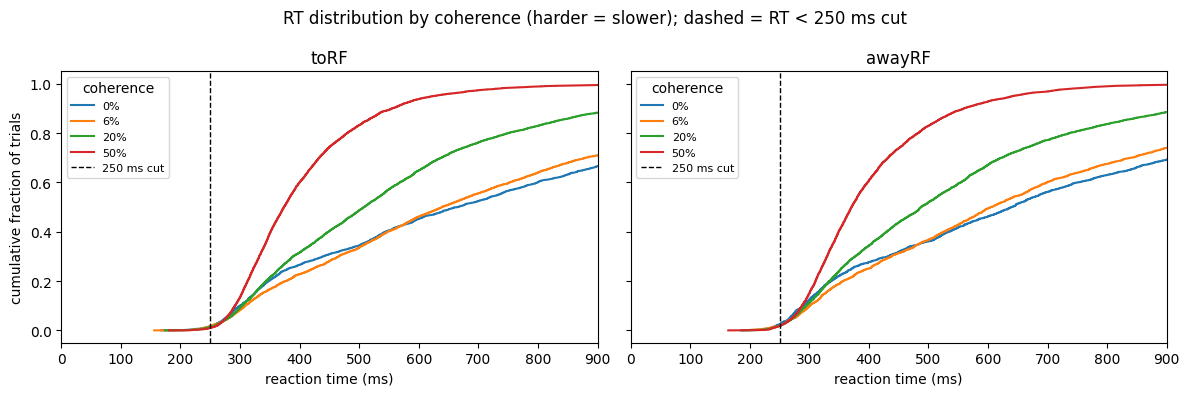

In [4]:
# --- Fig 1: RT distribution (ECDF) by abs_coherence, each direction separately ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, direction in zip(axes, ["toRF", "awayRF"]):
    direction_trials = trial_info[trial_info.prior_direction == direction]
    for level in np.sort(direction_trials.abs_coherence.unique()):
        reaction_times = np.sort(direction_trials.reaction_time[direction_trials.abs_coherence == level].values)
        ax.plot(reaction_times, np.arange(1, len(reaction_times) + 1) / len(reaction_times), label=f"{int(round(level*100))}%")
    ax.axvline(RT_TRIM_MS, color="k", ls="--", lw=1, label=f"{RT_TRIM_MS} ms cut")
    ax.set_xlim(0, 900); ax.set_title(direction); ax.set_xlabel("reaction time (ms)")
    ax.legend(title="coherence", fontsize=8)
axes[0].set_ylabel("cumulative fraction of trials")
fig.suptitle("RT distribution by coherence (harder = slower); dashed = RT < 250 ms cut")
plt.tight_layout(); plt.show()